# Load Kaggle dataset into notebook

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("hemanthsai7/solar-panel-dust-detection")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/hemanthsai7/solar-panel-dust-detection


# Split into test, train and valid in the local directory

In [2]:
import os
import shutil
import random
from pathlib import Path

# ── CONFIG ────────────────────────────────────────────────────────────────────
SOURCE_DIR  = f'{path}/Detect_solar_dust'          
OUTPUT_DIR  = Path('datasets')    
TRAIN_RATIO = 0.80
VAL_RATIO   = 0.10
TEST_RATIO  = 0.10               # must sum to 1.0
SEED        = 36
EXTENSIONS  = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
# ──────────────────────────────────────────────────────────────────────────────

assert abs(TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0) < 1e-6, \
    "Ratios must sum to 1.0"

random.seed(SEED)

source = Path(SOURCE_DIR)
output = Path(OUTPUT_DIR)

# Discover class folders
class_dirs = [d for d in source.iterdir() if d.is_dir()]
assert len(class_dirs) == 2, \
    f"Expected 2 class folders, found {len(class_dirs)}: {[d.name for d in class_dirs]}"

print(f"Classes found: {[d.name for d in class_dirs]}\n")

splits = ["train", "val", "test"]

for class_dir in class_dirs:
    class_name = class_dir.name

    # Collect all image files
    images = [
        f for f in class_dir.iterdir()
        if f.is_file() and f.suffix.lower() in EXTENSIONS
    ]

    if not images:
        print(f"  WARNING: No images found in '{class_name}', skipping.")
        continue

    random.shuffle(images)

    total      = len(images)
    train_end  = int(total * TRAIN_RATIO)
    val_end    = train_end + int(total * VAL_RATIO)

    split_files = {
        "train": images[:train_end],
        "val":   images[train_end:val_end],
        "test":  images[val_end:],
    }

    print(f"Class: {class_name}  |  Total: {total}")
    for split, files in split_files.items():
        dest = output / split / class_name
        dest.mkdir(parents=True, exist_ok=True)

        for f in files:
            shutil.copy2(f, dest / f.name)

        print(f"  {split:>5}: {len(files)} images  →  {dest}")

    print()


print("SPLIT SUMMARY")

for split in splits:
    split_path = output / split
    if not split_path.exists():
        continue
    total = sum(
        len(list((split_path / c).glob("*")))
        for c in os.listdir(split_path)
        if (split_path / c).is_dir()
    )
    class_counts = {
        c: len(list((split_path / c).glob("*")))
        for c in os.listdir(split_path)
        if (split_path / c).is_dir()
    }
    print(f"{split:>5}: {total:>4} total  |  {class_counts}")

print(f"\nOutput saved to: {output.resolve()}")

Classes found: ['Dusty', 'Clean']

Class: Dusty  |  Total: 1069
  train: 855 images  →  datasets/train/Dusty
    val: 106 images  →  datasets/val/Dusty
   test: 108 images  →  datasets/test/Dusty

Class: Clean  |  Total: 1493
  train: 1194 images  →  datasets/train/Clean
    val: 149 images  →  datasets/val/Clean
   test: 150 images  →  datasets/test/Clean

SPLIT SUMMARY
train: 2049 total  |  {'Dusty': 855, 'Clean': 1194}
  val:  255 total  |  {'Dusty': 106, 'Clean': 149}
 test:  258 total  |  {'Dusty': 108, 'Clean': 150}

Output saved to: /kaggle/working/datasets


# Import the necesary libraries

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Set random seeds for numpy and tensorflow

In [4]:
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED']= str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
print(f'Random seed set to : {SEED}')

Random seed set to : 36


# Set global hyperparameters.

In [5]:
DATASET_DIR = 'datasets'
IMG_SIZE = (224, 224)
BATCH_SIZE = 36
EPOCHS = 35
LR = 1e-4

# Load the training dataset 

In [6]:
train_data = tf.keras.utils.image_dataset_from_directory(
    f'{DATASET_DIR}/train',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle= True,
)

Found 2049 files belonging to 2 classes.


I0000 00:00:1785501565.913707      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


# Load the test dataset

In [7]:
test_data = tf.keras.utils.image_dataset_from_directory(
     f'{DATASET_DIR}/test',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle= False
)

Found 258 files belonging to 2 classes.


# Load the validation dataset

In [8]:
val_data = tf.keras.utils.image_dataset_from_directory(
     f'{DATASET_DIR}/val',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle= False
)

Found 255 files belonging to 2 classes.


# Get class names and number of classes

In [9]:
CLASS_NAMES = train_data.class_names
print(f'Classes:  {CLASS_NAMES}')

Classes:  ['Clean', 'Dusty']


# Visualise dataset samples

In [10]:
for images, labels in train_data.take(1):
    fixed_images = images.numpy()
    fixed_labels = labels.numpy()

# Optimise the data pipeline.

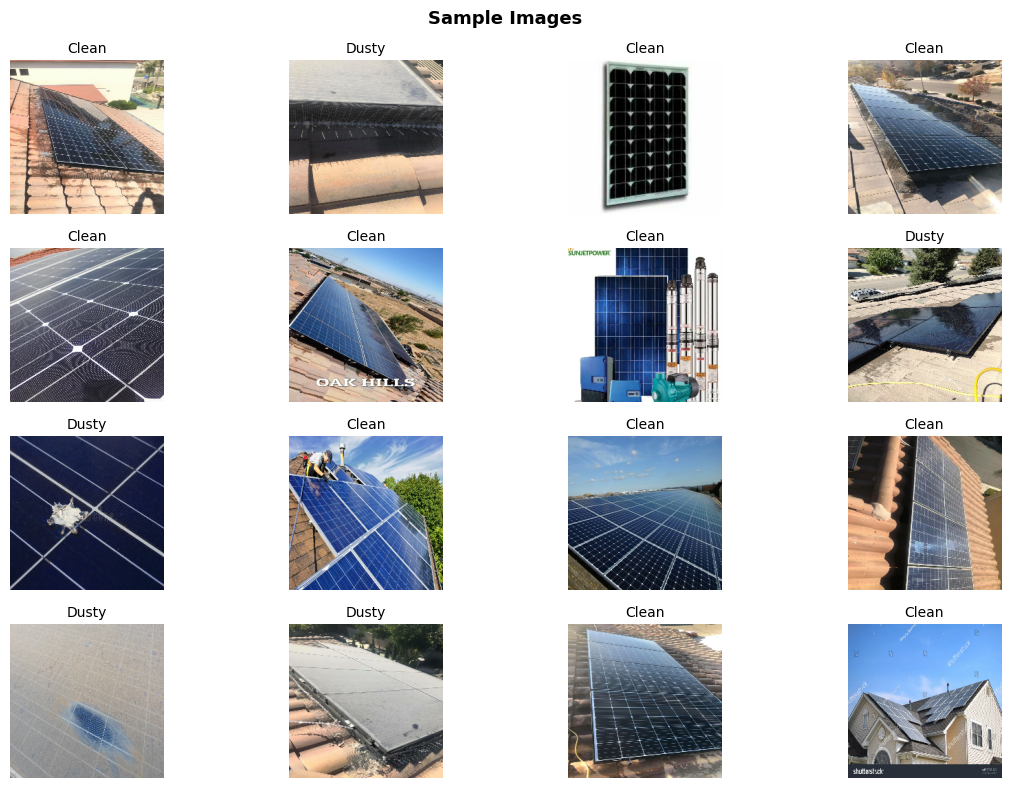

In [11]:
plt.figure(figsize=(12, 8))
for i in range(min(16, len(fixed_images))):
    ax = plt.subplot(4, 4, i + 1)
    plt.imshow(fixed_images[i].astype('uint8'))
    plt.title(CLASS_NAMES[fixed_labels[i]], fontsize=10) 
    plt.axis('off')
plt.suptitle('Sample Images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
AUTOTUNE = tf.data.AUTOTUNE
train_data = (train_data.cache().shuffle(800).prefetch(buffer_size=AUTOTUNE))
val_data = (val_data.cache().prefetch(buffer_size=AUTOTUNE))
test_data = (test_data.cache().prefetch(buffer_size=AUTOTUNE))

 # Define the data augmentation pipeline.

In [13]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
], name= 'data_augumentation')

# Visualise augmentation effects on one image

Corrupt JPEG data: 1 extraneous bytes before marker 0xed


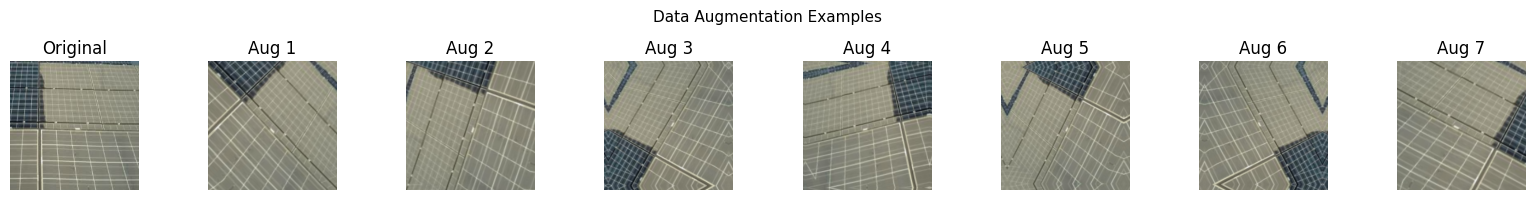

In [14]:
for images, _ in train_data.take(1):
    sample = images[0:1] 
    break

fig, axes = plt.subplots(1, 8, figsize=(16, 2))
axes[0].imshow(sample[0].numpy().astype('uint8'))
axes[0].set_title('Original'); axes[0].axis('off')

for i in range(1, 8):
    aug_img = data_augmentation(sample,training=True)[0].numpy().astype('uint8')
    axes[i].imshow(aug_img)
    axes[i].set_title(f'Aug {i}')
    axes[i].axis('off')

plt.suptitle('Data Augmentation Examples', fontsize=11)
plt.tight_layout()
plt.show()

# Define shared callbacks and utilities.

In [15]:
os.makedirs('models', exist_ok=True)

def make_callbacks(name):
    
    return [ tf.keras.callbacks.ModelCheckpoint(
        filepath=f'models/{name}_best.keras',
        monitor='val_accuracy', save_best_only=True,
        ),
        tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=8,
        restore_best_weights=True, verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.3,
        patience=4, min_lr=1e-7, verbose=1
        ),
        ]
def plot_learning_curves(history, title='Learning Curves'):
    
    acc= history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Accuracy', linewidth=2)
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', linewidth=2,linestyle='--')
    plt.legend()
    plt.title(f'{title} — Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.grid(alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss', linewidth=2)
    plt.plot(epochs_range, val_loss, label='Validation Loss', linewidth=2,linestyle='--')
    plt.legend()
    plt.title(f'{title} — Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

def evaluate_model(model, dataset, class_names, title='Model', results_dir='./'):
    y_true, y_pred, y_prob = [], [], []
    for images, labels in dataset:
        probs = model.predict(images, verbose=0).squeeze()  # (batch,)
        preds = (probs >= 0.5).astype(int)
        y_prob.append(probs)
        y_pred.append(preds)
        y_true.append(labels.numpy())
    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    y_prob = np.concatenate(y_prob)
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))
    cm = confusion_matrix(y_true, y_pred)
    
    print(cm)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, cmap='Blues', cbar=False, annot=True, fmt='',
                xticklabels=class_names, yticklabels=class_names,
                annot_kws={'fontsize': 9, 'fontweight': 'bold'})
    plt.title(f'{title} — Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()
    return accuracy_score(y_true, y_pred)
print('Callbacks and utility functions defined.')

Callbacks and utility functions defined.


# Build the Custom CNN Architecture

In [16]:
INPUT_SHAPE = (IMG_SIZE[0],IMG_SIZE[1] , 3)

def build_custom_cnn(input_shape, augmentation):
   
    inputs = tf.keras.Input(shape=input_shape)
    x = augmentation(inputs)
   
    x = tf.keras.layers.Rescaling(1.0 / 255)(x)
    
    # Block 1: 32 filters
    x = tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.Dropout(0.25)(x)
    
    # Block 2: 64 filters
    x = tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.Dropout(0.25)(x)
    
    # Block 3: 128 filters
    x = tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.Dropout(0.25)(x)
    
    # Classification Head
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
    return tf.keras.Model(inputs, outputs, name='custom_cnn')
    
cnn_model = build_custom_cnn(INPUT_SHAPE, data_augmentation)
cnn_model.summary()

Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augumentation (Sequential) │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             

 Total params: 322,081 (1.23 MB)

 Trainable params: 321,185 (1.23 MB)

 Non-trainable params: 896 (3.50 KB)

# Compile the custom CNN mdel.

In [17]:
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

# Train the model and save the training history

In [18]:
cnn_history = cnn_model.fit(
    train_data, validation_data=val_data,epochs=EPOCHS,
    callbacks=make_callbacks('custom_cnn'), verbose=1)

Epoch 1/35


E0000 00:00:1785501592.497040      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/custom_cnn_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


57/57 ━━━━━━━━━━━━━━━━━━━━ 18s 203ms/step - accuracy: 0.6989 - loss: 0.6069 - val_accuracy: 0.4157 - val_loss: 0.7406 - learning_rate: 1.0000e-04
Epoch 2/35
57/57 ━━━━━━━━━━━━━━━━━━━━ 10s 169ms/step - accuracy: 0.7243 - loss: 0.5541 - val_accuracy: 0.4157 - val_loss: 0.9102 - learning_rate: 1.0000e-04
Epoch 3/35
57/57 ━━━━━━━━━━━━━━━━━━━━ 10s 169ms/step - accuracy: 0.7413 - loss: 0.5247 - val_accuracy: 0.4157 - val_loss: 1.4419 - learning_rate: 1.0000e-04
Epoch 4/35
57/57 ━━━━━━━━━━━━━━━━━━━━ 10s 169ms/step - accuracy: 0.7535 - loss: 0.5084 - val_accuracy: 0.4157 - val_loss: 1.6174 - learning_rate: 1.0000e-04
Epoch 5/35
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.7731 - loss: 0.5036
Epoch 5: ReduceLROnPlateau reducing learning rate to 2.9999999242136255e-05.
57/57 ━━━━━━━━━━━━━━━━━━━━ 10s 169ms/step - accuracy: 0.7687 - loss: 0.4994 - val_accuracy: 0.4157 - val_loss: 1.6280 - learning_rate: 1.0000e-04
Epoch 6/35
57/57 ━━━━━━━━━━━━━━━━━━━━ 10s 169ms/step - accuracy: 0.7750 - 

# Evaluate the Custom CNN on validation dataset

In [19]:
cnn_val_loss, cnn_val_acc = cnn_model.evaluate(val_data, verbose=0)
print(f'Custom CNN -> val_loss: {cnn_val_loss:.4f}')
print(f'val_accuracy: {cnn_val_acc:.4f}')

Custom CNN -> val_loss: 0.5187
val_accuracy: 0.7647


# Visualise the Learning curves for the Custom CNN

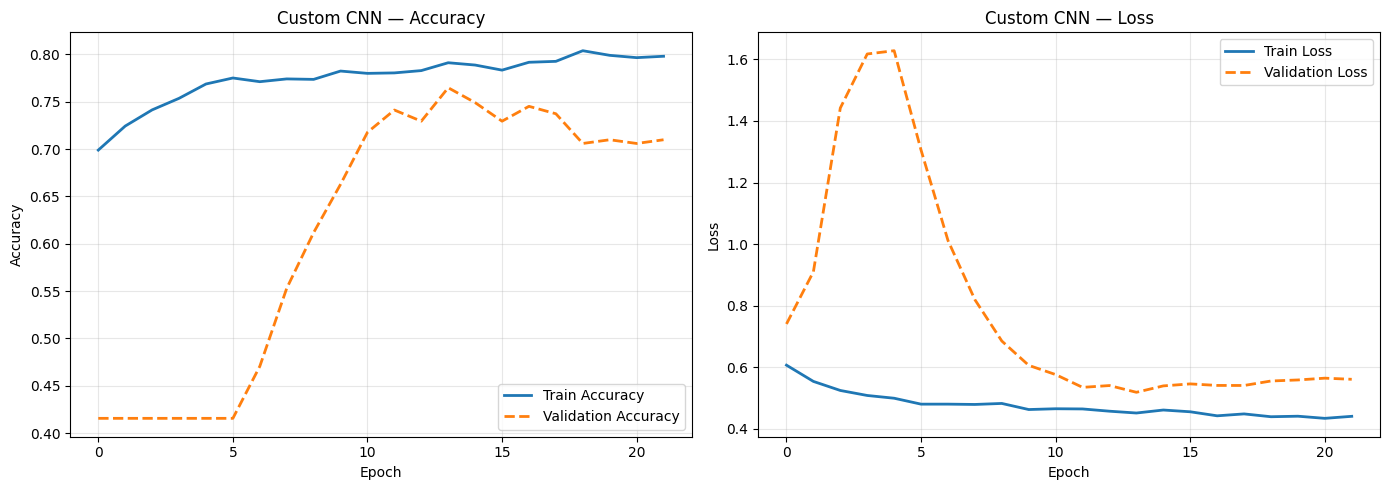

In [20]:
plot_learning_curves(cnn_history, 'Custom CNN')

# Evaluate the Custom CNN on test dataset

In [21]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(test_data, verbose=0)
print(f'Custom CNN -> test_loss: {cnn_val_loss:.4f}')
print(f'test_accuracy: {cnn_test_acc:.4f}')

Custom CNN -> test_loss: 0.5187
test_accuracy: 0.7752


# Evalutate model and plot confusion matrix for custom cnn model

2026-07-31 12:43:32.235477: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



Classification Report:
              precision    recall  f1-score   support

       Clean     0.8710    0.7200    0.7883       150
       Dusty     0.6866    0.8519    0.7603       108

    accuracy                         0.7752       258
   macro avg     0.7788    0.7859    0.7743       258
weighted avg     0.7938    0.7752    0.7766       258

[[108  42]
 [ 16  92]]


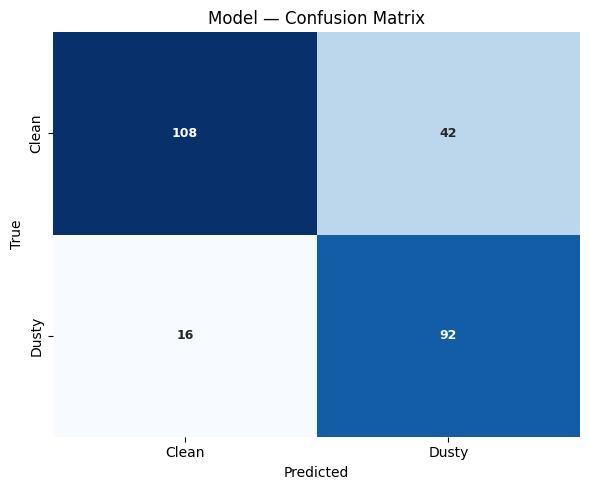

0.7751937984496124

In [22]:
evaluate_model(cnn_model, test_data, CLASS_NAMES)

#  Build the Transfer Learning Model

In [23]:
def build_transfer_model(input_shape, augmentation):
   

    base_model = tf.keras.applications.MobileNetV3Small(
            weights='imagenet',
            input_shape=input_shape,
            include_top=False,
        )
    preprocess_fn = tf.keras.applications.mobilenet_v3.preprocess_input
    model_name= 'mobilenetv3small_transfer'
    
   
    # Freeze all base layers for feature extraction (no training)
    base_model.trainable = False
    print(f'Base model: {base_model.name}')
    print(f'Trainable layers: {sum(1 for l in base_model.layers if l.trainable)} / {len(base_model.layers)}')
    
    # Build the model graph
    inputs = tf.keras.Input(shape=input_shape)
    x = augmentation(inputs)
    x = preprocess_fn(x) 
    x = base_model(x, training=False)
    # frozen inference mode
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
    return tf.keras.Model(inputs, outputs, name=model_name), base_model
    
tl_model, base_model = build_transfer_model(INPUT_SHAPE, data_augmentation)
tl_model.summary()

4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base model: MobileNetV3Small
Trainable layers: 0 / 157


Model: "mobilenetv3small_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augumentation (Sequential) │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       147,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,087,089 (4.15 MB)

 Trainable params: 147,969 (578.00 KB)

 Non-trainable params: 939,120 (3.58 MB)

# Compile Transfer learning model 

In [24]:

tl_model.compile(
optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
loss='binary_crossentropy',
metrics=['accuracy'],
)



# Train the model.

In [25]:
tl_history = tl_model.fit(
    train_data,validation_data=val_data,
    epochs=EPOCHS,callbacks=make_callbacks('tl_feature_extraction'),
    verbose=1,
)


Epoch 1/35
57/57 ━━━━━━━━━━━━━━━━━━━━ 9s 57ms/step - accuracy: 0.6213 - loss: 0.6657 - val_accuracy: 0.7020 - val_loss: 0.5720 - learning_rate: 1.0000e-04
Epoch 2/35
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.7326 - loss: 0.5397 - val_accuracy: 0.7373 - val_loss: 0.4986 - learning_rate: 1.0000e-04
Epoch 3/35
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.7482 - loss: 0.5089 - val_accuracy: 0.7686 - val_loss: 0.4647 - learning_rate: 1.0000e-04
Epoch 4/35
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.7628 - loss: 0.4928 - val_accuracy: 0.7725 - val_loss: 0.4589 - learning_rate: 1.0000e-04
Epoch 5/35
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.7828 - loss: 0.4673 - val_accuracy: 0.8000 - val_loss: 0.4382 - learning_rate: 1.0000e-04
Epoch 6/35
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.7789 - loss: 0.4551 - val_accuracy: 0.7922 - val_loss: 0.4338 - learning_rate: 1.0000e-04
Epoch 7/35
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.8009 

# Evaluate the Transfer Learning Model on validation dataset

MobileNetV3 TL -> val_loss: 0.3851
MobileNetV3 TL -> val_accuracy: 0.8039


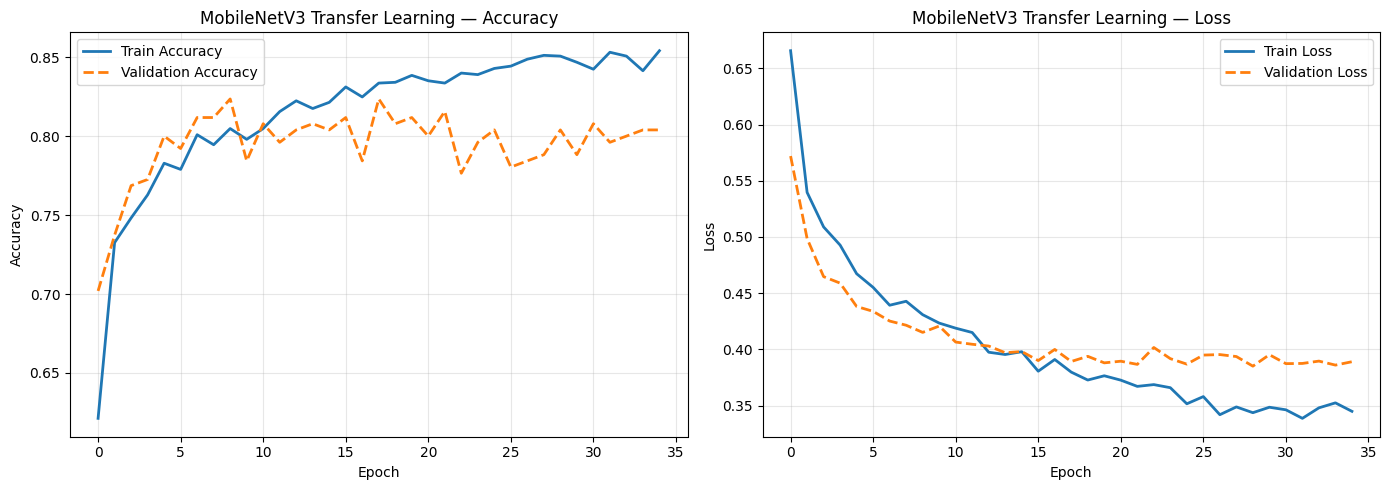

In [26]:
tl_val_loss, tl_val_acc = tl_model.evaluate(val_data, verbose=0)
print(f'MobileNetV3 TL -> val_loss: {tl_val_loss:.4f}')
print(f'MobileNetV3 TL -> val_accuracy: {tl_val_acc:.4f}')
plot_learning_curves(tl_history, 'MobileNetV3 Transfer Learning')

# Evaluate the Transfer Learning Model on test dataset

MobileNetV3 TL -> val_loss: 0.3829
MobileNetV3 TL -> val_accuracy: 0.8450


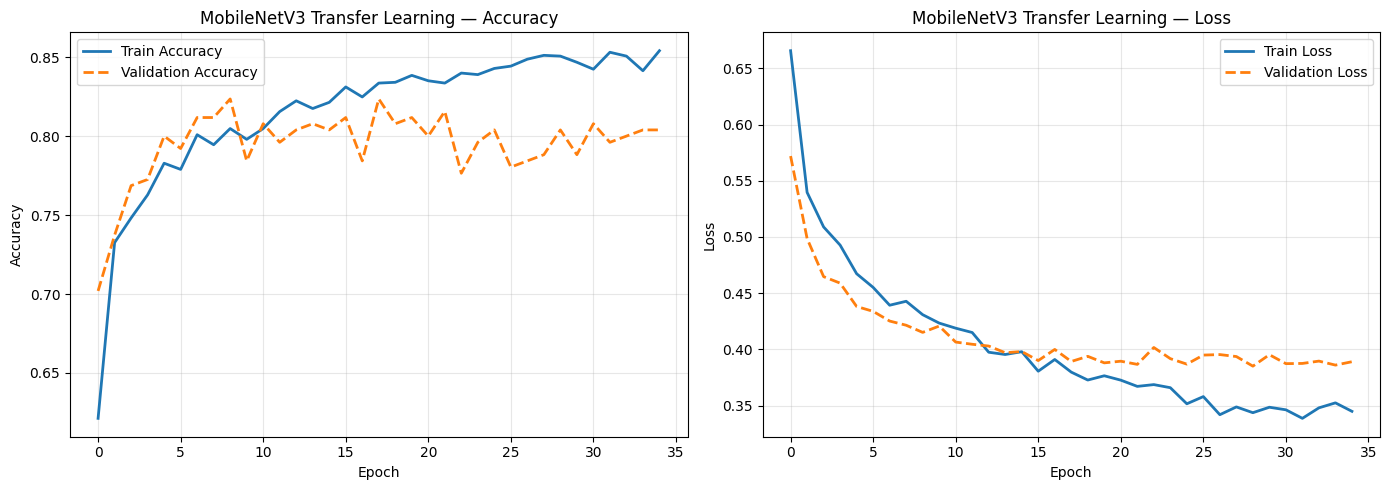

In [27]:
tl_test_loss, tl_test_acc = tl_model.evaluate(test_data, verbose=0)
print(f'MobileNetV3 TL -> val_loss: {tl_test_loss:.4f}')
print(f'MobileNetV3 TL -> val_accuracy: {tl_test_acc:.4f}')
plot_learning_curves(tl_history, 'MobileNetV3 Transfer Learning')

# Evalutate model and plot confusion matrix for Transfer learning

2026-07-31 12:44:29.608774: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



Classification Report:
              precision    recall  f1-score   support

       Clean     0.8395    0.9067    0.8718       150
       Dusty     0.8542    0.7593    0.8039       108

    accuracy                         0.8450       258
   macro avg     0.8468    0.8330    0.8379       258
weighted avg     0.8456    0.8450    0.8434       258

[[136  14]
 [ 26  82]]


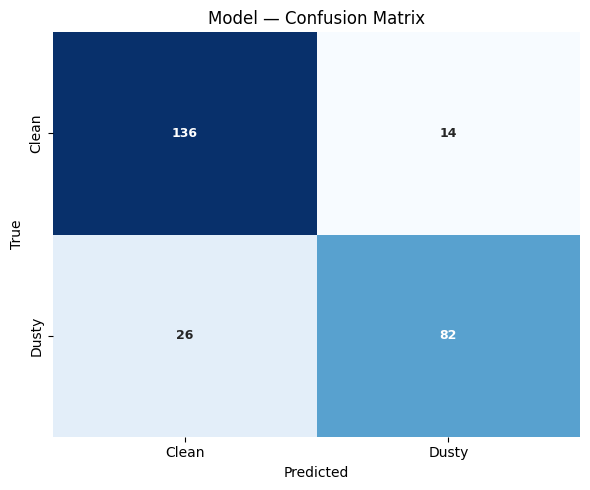

0.8449612403100775

In [28]:
evaluate_model(tl_model, test_data, CLASS_NAMES)

# Side-by-side model comparison.

In [29]:
results = {
'Custom CNN': {'acc': cnn_test_acc, 'params': cnn_model.count_params()},
'MobileNetV3 (TL)':{'acc': tl_test_acc,'params':tl_model.count_params()}}

print(f'{"Model":<25} {"Test Acc":>10} {"Params":>14}')
print('-' * 55)
for name, vals in results.items():
    print(f'{name:<25} {vals["acc"]:>10.4f} {vals["params"]:>14,}')

Model                       Test Acc         Params
-------------------------------------------------------
Custom CNN                    0.7752        322,081
MobileNetV3 (TL)              0.8450      1,087,089


# Test the model with new image.

In [30]:
def predict_image(img_path, models_dict, class_names, image_size=IMG_SIZE):
    
    img = tf.keras.utils.load_img(img_path, target_size=image_size)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) 
    
    plt.figure(figsize=(3, 3))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Input Image')
    plt.show()
    
    print(f'\nPredictions for: {img_path}')
    print('-' * 40)
    for name, mdl in models_dict.items():
        prob = mdl.predict(img_array, verbose=0)[0][0]
        label = class_names[int(prob >= 0.5)]
        print(f'{name:<25}: {label} (p={prob:.4f})')

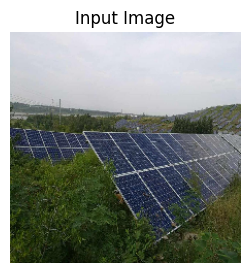


Predictions for: /kaggle/working/datasets/test/Clean/Imgclean_390_0.jpg
----------------------------------------
Custom CNN               : Clean (p=0.1625)
MobileNetV3 TL           : Clean (p=0.0351)


2026-07-31 12:50:03.009207: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


In [34]:
image_path = '/kaggle/working/datasets/test/Clean/Imgclean_390_0.jpg'
predict_image(
    image_path,
    {'Custom CNN': cnn_model, 'MobileNetV3 TL': tl_model},CLASS_NAMES
)

# Save Models 

In [32]:
os.makedirs('models', exist_ok=True)
cnn_model.save('models/custom_cnn.keras')
tl_model.save('models/mobilenetv3_transfer.keras')
print('Models saved:')
print(' models/custom_cnn.keras')
print(' models/mobilenetv3_transfer.keras')

Models saved:
 models/custom_cnn.keras
 models/mobilenetv3_transfer.keras
